In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_excel('Online Retail.xlsx')

In [6]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [7]:
df.shape

(541909, 8)

In [9]:
# Drop Null Customer Id 
df.dropna(subset=['CustomerID'], inplace=True)
# Remove Cancelled Orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.shape

(397884, 9)

In [10]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo':   'nunique',
    'TotalPrice':  'sum'
}).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.describe()
# Recency: days since last purchase 
# Frequency: number of unique orders
# Monetary: total money spent

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

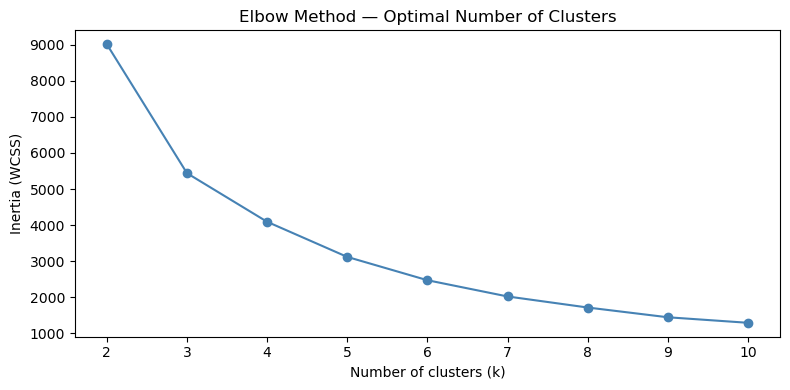

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [15]:
# Scale features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
inertia = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()
#  Train final model with K=4 
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm['Cluster'].value_counts()

Silhouette Score: 0.6162


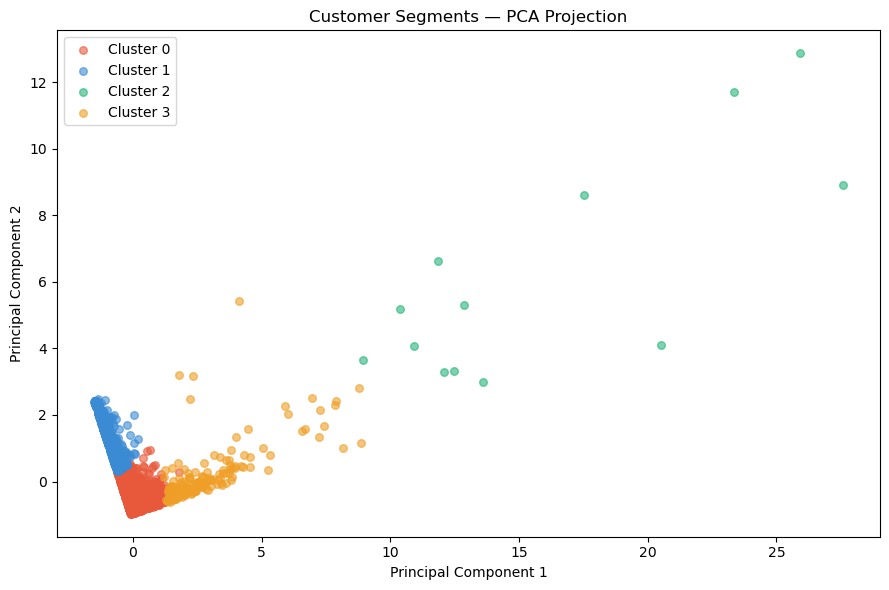

In [16]:
score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f"Silhouette Score: {score:.4f}")
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = pca_coords[:, 0]
rfm['PCA2'] = pca_coords[:, 1]
plt.figure(figsize=(9, 6))
colors = ['#E8593C', '#3B8BD4', '#27B57A', '#EF9F27']
for cluster in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == cluster]
    plt.scatter(subset['PCA1'], subset['PCA2'],
                label=f'Cluster {cluster}',
                alpha=0.6, s=30, color=colors[cluster])
plt.title('Customer Segments — PCA Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('cluster_plot.png', dpi=150)
plt.show()

In [17]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
print(cluster_summary)
segment_names = {
    0: 'Champions',
    1: 'Lost Customers',
    2: 'Loyal Customers',
    3: 'At-Risk Customers'
}
rfm['Segment'] = rfm['Cluster'].map(segment_names)
rfm.to_csv('customer_segments.csv', index=False)
print("\nSegment distribution:")
rfm['Segment'].value_counts()

         Recency  Frequency  Monetary
Cluster                              
0           43.7        3.7    1359.0
1          248.1        1.6     480.6
2            7.4       82.5  127338.3
3           15.5       22.3   12709.1

Segment distribution:


Segment
Champions            3054
Lost Customers       1067
At-Risk Customers     204
Loyal Customers        13
Name: count, dtype: int64